In [108]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Import Library
Baris kode di atas digunakan untuk mengimpor berbagai library yang mendukung alur komputasi pengolahan citra, ekstraksi fitur, dan klasifikasi machine learning. Modul `os` digunakan untuk interaksi dengan sistem operasi seperti manajemen direktori file. `OpenCV` berfungsi untuk membaca dan mengonversi format matriks citra, sementara `Matplotlib` digunakan untuk memvisualisasikan data citra atau grafik ke layar. `NumPy` berfokus pada komputasi matematis dan manipulasi array matriks, dan `Pandas` berfungsi untuk menampung serta mengelola data hasil ekstraksi ke dalam bentuk tabel terstruktur.

Untuk tahap ekstraksi fitur tekstur, modul `skimage.feature` memanggil fungsi `graycomatrix` dan `graycoprops` guna membangun Gray-Level Co-Occurrence Matrix (GLCM) dan mengalkulasi metrik statistiknya, ditambah fungsi `entropy` dari `scipy.stats` untuk mengukur tingkat kompleksitas distribusi piksel.

Pada tahap pemodelan dan klasifikasi, pustaka `scikit-learn` digunakan secara komprehensif. Fungsi `train_test_split` dan `cross_val_predict` mengatur pembagian skema data latih dan data uji. Pemodelan algoritma klasifikasi diakomodasi melalui pemanggilan `RandomForestClassifier`, `SVC` (Support Vector Machine), dan `KNeighborsClassifier`. Terakhir, performa akurasi pemodelan diukur secara matematis menggunakan fungsi metrik bawaan seperti `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, dan `classification_report`, yang kemudian dianalisis secara visual melalui pembentukan `confusion_matrix` dan `ConfusionMatrixDisplay` dengan dukungan grafis dari library `Seaborn`.

## Data Loading
Kode di bawah ini digunakan untuk memuat dan mengorganisasi dataset citra digital secara iteratif berdasarkan struktur direktori ke dalam format matriks. Proses diawali dengan menginisialisasi variabel list kosong untuk menampung matriks citra, label kelas, nama file, serta dictionary untuk menghitung frekuensi data. Melalui nested looping, program menelusuri setiap sub-folder di dalam direktori `"dataset"`. Pada setiap iterasinya, fungsi `cv.imread()` dipanggil untuk membaca file citra dan `cv.resize()` digunakan untuk menyamakan resolusi citra ke ukuran tetap 512x256 piksel. Eksekusi ini dibatasi secara eksplisit maksimal 100 citra per kelas menggunakan instruksi kondisional `break`. Matriks citra dan label yang valid kemudian disematkan ke dalam list terkait dan dikonversi menjadi format `NumPy` array agar kompatibel untuk komputasi pemodelan. Pada tahap akhir, program mencetak teks ringkasan jumlah data di terminal dan memvisualisasikan distribusi jumlah citra per kelas ke dalam bentuk grafik batang menggunakan pemanggilan fungsi `sns`.`barplot()` dari library `Seaborn` serta dikonfigurasi sumbu koordinatnya menggunakan `matplotlib.pyplot`. Jumlah dari masing-masing jenis citra ditampilkan dengan diagram batang.

Loading dataset...
Dataset loaded with 200 images across 2 classes.
 - Class 'Diseased': 100 images
 - Class 'Healthy': 100 images


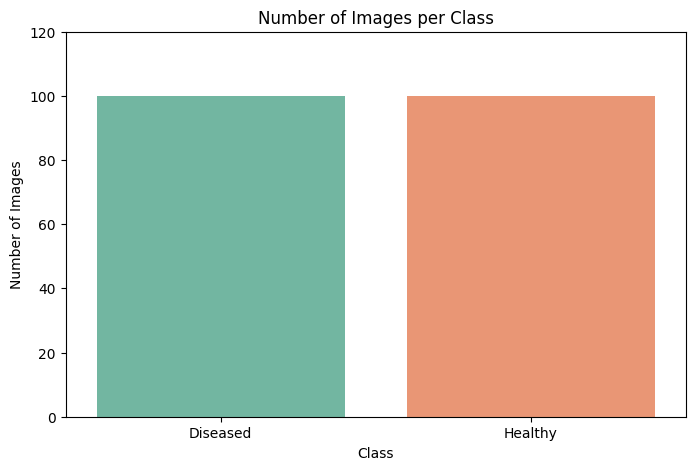

In [109]:
data = []
labels = []
file_name = []
class_counter = {}

target_size = (512, 256) 

for sub_folder in os.listdir("dataset\\"):
    sub_folder_path = os.path.join("dataset\\", sub_folder)
    
    if os.path.isdir(sub_folder_path): 
        sub_folder_files = os.listdir(sub_folder_path)
        class_counter[sub_folder] = 0
        
        for filename in sub_folder_files:
            if class_counter[sub_folder] >= 100:
                break
                
            img_path = os.path.join("dataset\\", sub_folder, filename)
            img = cv.imread(img_path)
            
            if img is not None:
                img_resized = cv.resize(img, target_size)
                
                data.append(img_resized)
                labels.append(sub_folder)
                file_name.append(filename)
                
                class_counter[sub_folder] += 1
        
data = np.array(data)
labels = np.array(labels)

print("Loading dataset...")
print(f"Dataset loaded with {len(data)} images across {len(class_counter)} classes.")
for folder_name, total_files in class_counter.items():
    print(f" - Class '{folder_name}': {total_files} images")

plt.figure(figsize=(8, 5))
sns.barplot(
    x=list(class_counter.keys()),
    y=list(class_counter.values()),
    hue=list(class_counter.keys()),  
    palette="Set2",
    legend=False  
)
plt.title('Number of Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.ylim(0, 120)
plt.show()

### Sampel Citra
Kode di bawah ini digunakan untuk memvisualisasikan satu citra representatif dari masing-masing kelas dalam dataset. Fungsi `show_sample_images` digunakan untuk memvisualisasikan satu contoh citra representatif dari masing-masing kelas. Melalui perulangan, program memfilter matriks citra berdasarkan kecocokan label kelasnya. Jika data kelas tersebut tersedia, citra pada indeks ke-10 akan diekstraksi, dikonversi dari format warna BGR ke RGB menggunakan `cv.cvtColor()`, lalu di-render secara berdampingan ke dalam subplot berukuran 1x2 menggunakan `Matplotlib`. Pada baris terakhir, fungsi ini dipanggil untuk dieksekusi dengan melewatkan argumen `data`, `labels`, dan `class_counter`.

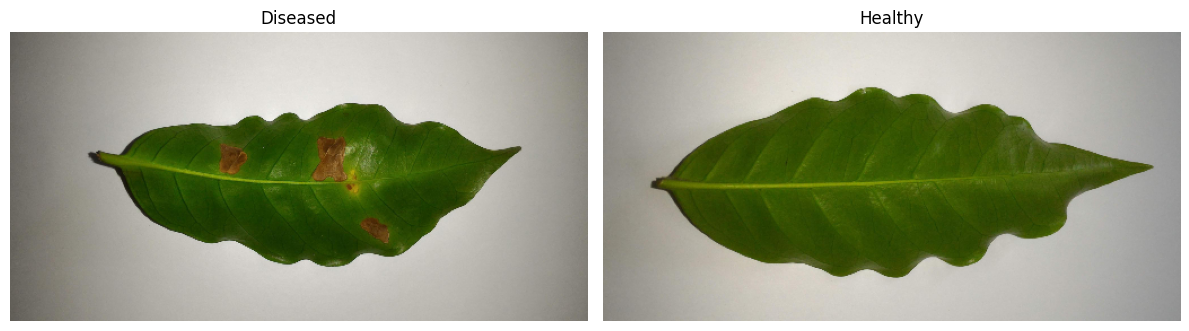

In [110]:
def show_sample_images(images, labels, class_names):
    plt.figure(figsize=(12, 6))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == class_name]
        if len(class_images) > 0:
            plt.subplot(1, 2, i + 1)
            plt.imshow(cv.cvtColor(class_images[10], cv.COLOR_BGR2RGB)) 
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(data, labels, class_counter)

### Citra Grayscale
Kode di bawah ini digunakan untuk mengubah seluruh matriks citra berwarna pada dataset menjadi format grayscale. Melalui perulangan, setiap citra di dalam variabel data dikonversi secara individual menggunakan fungsi `cv.cvtColor()` dengan parameter `cv.COLOR_BGR2GRAY`. Matriks hasil konversi ditampung ke dalam sebuah list baru, lalu diubah secara kolektif menjadi `NumPy` array. Pada baris terakhir, fungsi `show_sample_images()` dipanggil untuk memvisualisasikan contoh dari citra yang telah berubah format menjadi keabuan.

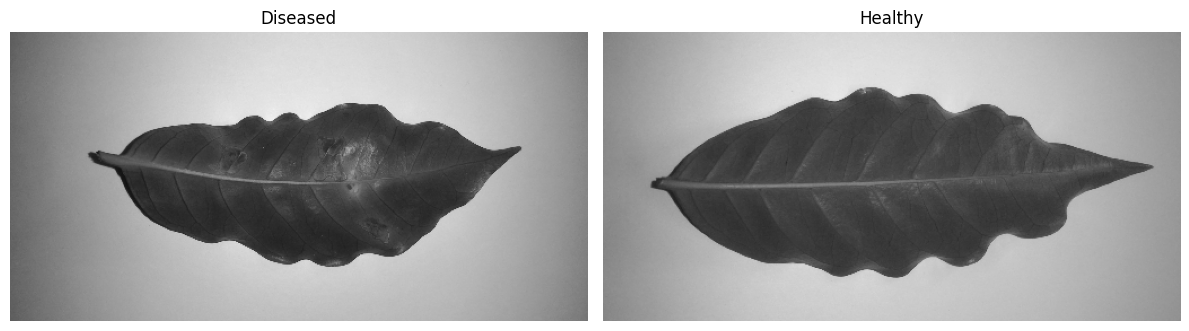

In [111]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_counter)

## Data Preparation

### Define Preprocessing Function


In [112]:
def manual_median_filter(img, size=3):
    height, width = img.shape
    pad = size // 2
    
    padded = np.pad(img, pad, mode='edge').astype(np.uint8)
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.median(region)
    
    return canvas

### Fungsi Median
Kode di atas ini adalah fungsi `manual_median_filter` menerapkan penyaringan spasial pada citra. Kode mengawali proses dengan menambahkan padding pada tepi matriks menggunakan `np.pad()` agar piksel terluar dapat dievaluasi. Melalui nested loop, program mengekstrak blok area piksel `(region)` sesuai ukuran kernel, menghitung nilai tengahnya menggunakan `np.median()`, dan langsung menempatkan hasil komputasi tersebut ke koordinat yang bersesuaian pada matriks keluaran `(canvas)`.

In [113]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='edge') 
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i : i + size, j : j + size]
            canvas[i, j] = np.sum(region * kernel)
            
    return np.clip(canvas, 0, 255).astype(np.uint8)

k_sharp = np.array([[0, -1, 0], 
                    [-1, 5, -1], 
                    [0, -1, 0]])

### Fungsi Konvolusi
Kode di atas ini adalah fungsi `convolution` mengeksekusi operasi penyaringan spasial secara manual dengan mengalikan area piksel citra terhadap matriks kernel. Kode diawali dengan memberikan padding pada tepi citra masukan agar batas luarnya dapat dihitung. Melalui iterasi bersarang, nilai dari setiap blok area piksel `(region)` dikalikan secara elemen-per-elemen dengan kernel dan seluruhnya dijumlahkan untuk menggantikan nilai piksel pusat pada matriks keluaran `(canvas)`. Hasil komputasi akhir dibatasi pada rentang intensitas standar 0-255 menggunakan fungsi `np.clip()` dan dikonversi ke tipe data `uint8`. Selanjutnya, variabel `k_sharp` mendefinisikan kernel berukuran 3x3 yang berfungsi sebagai filter untuk mempertegas garis tepi, dan list kosong `img_sharpened` diinisialisasi untuk menampung matriks citra hasil komputasi dari proses tersebut.

In [114]:
def ekualisasi_histogram(citra):
    if citra.dtype != np.uint8:
        if citra.max() <= 1.0:
            citra = (citra * 255).astype(np.uint8)
        else:
            citra = citra.astype(np.uint8)

    panjang, lebar = citra.shape

    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    cdf = np.zeros(256, dtype=int)
    akumulasi = 0
    for i in range(256):
        akumulasi += histogram[i]
        cdf[i] = akumulasi

    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    denominator = (panjang * lebar) - cdf_min
    
    if denominator == 0:
        cdf_norm = cdf
    else:
        cdf_norm = np.round((cdf - cdf_min) / denominator * 255).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

### Fungsi Ekualisasi Histogram
Kode di atas ini adalah fungsi `ekualisasi_histogram` yang mengimplementasikan pemerataan kontras citra secara manual berdasarkan probabilitas nilai kumulatifnya. Proses diawali dengan memvalidasi dan mengonversi tipe data citra masukan ke format `uint8` (0-255). Melalui nested loop, program menghitung frekuensi kemunculan setiap nilai intensitas piksel untuk membangun matriks `histogram`, yang kemudian diakumulasikan secara sekuensial untuk membentuk Cumulative Distribution Function `(cdf)`. Nilai `cdf` tersebut selanjutnya dinormalisasi secara matematis agar nilainya terpetakan kembali ke dalam rentang skala 0-255. Pada tahap akhir, setiap nilai piksel dari citra asli dievaluasi dan diganti dengan intensitas baru yang telah diratakan merujuk pada indeks matriks `cdf_norm`, lalu dikembalikan sebagai matriks citra keluaran.

In [115]:
kernel3f1 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

### Kernel 3x3
Kode di atas digunakan untuk mendeklarasikan variabel matriks dua dimensi menggunakan library `NumPy`. Variabel  `kernel3f1` diinisialisasi sebagai matriks persegi berukuran 3x3. Matriks ini difungsikan sebagai elemen penstruktur atau kernel pembobot dasar yang dieksekusi untuk operasi-operasi pengolahan citra digital.

In [116]:
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            region = image[i - center:i + center + 1, j - center:j + center + 1]
            hasil[i, j] = np.max(region * kernel)
    return hasil

### Fungsi Dilasi
Kode di atas ini adalah fungsi `dilasi` yang mengimplementasikan operasi morfologi secara manual untuk mempertebal batas objek atau piksel bernilai tinggi pada citra. Proses diawali dengan mengambil dimensi matriks citra dan kernel, serta menentukan nilai tengah kernel sebagai acuan batas pemrosesan. Matriks keluaran hasil diinisialisasi dengan nilai nol berformat `uint8`. Melalui nested loop, iterasi dieksekusi secara terbatas hanya pada area interior citra, mengabaikan bagian tepi terluar karena tidak adanya proses penambahan batas padding. Pada setiap koordinat matriks, potongan area lokal `(region)` diekstrak, dikalikan secara elemen-per-elemen dengan matriks kernel, lalu dicari nilai intensitas tertingginya secara komputasi menggunakan `np.max()`. Nilai maksimum tersebut selanjutnya ditetapkan sebagai intensitas piksel pusat yang baru pada matriks `hasil`.

In [117]:
def erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height - center):
        for j in range(center, width - center):
            region = image[i - center:i + center + 1, j - center:j + center + 1]
            hasil[i, j] = np.min(region * kernel + (1 - kernel) * 255)
    return hasil

### Fungsi Erosi
Kode di atas ini adalah fungsi `erosi` yang mengimplementasikan operasi morfologi secara manual untuk mengikis batas objek atau mempersempit area piksel bernilai tinggi pada citra. Proses diawali dengan mengambil dimensi matriks citra dan kernel, serta menentukan nilai tengah kernel sebagai acuan batas pemrosesan. Matriks keluaran hasil diinisialisasi dengan nilai nol berformat `uint8`. Melalui nested loop, iterasi dieksekusi secara terbatas hanya pada area interior citra, mengabaikan bagian tepi terluar karena tidak adanya proses penambahan batas padding. Pada setiap koordinat matriks, potongan area lokal `(region)` diekstrak, dievaluasi terhadap matriks kernel dengan menambahkan nilai 255 pada area di luar bentuk kernel, lalu dicari nilai intensitas terendahnya secara komputasi menggunakan `np.min()`. Nilai minimum tersebut selanjutnya ditetapkan sebagai intensitas piksel pusat yang baru pada matriks `hasil`.

In [118]:
def get_edge(img, kx, ky):
    gx = convolution(img, kx)
    gy = convolution(img, ky)
    edge_img = np.abs(gx.astype(np.float32)) + np.abs(gy.astype(np.float32))
    return np.clip(edge_img, 0, 255).astype(np.uint8)

sobelX = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]], dtype=np.float32)

sobelY = np.array([[1, 2, 1], 
                   [0, 0, 0], 
                   [-1, -2, -1]], dtype=np.float32)

### Fungsi Edge Detection Sobel
Kode di atas ini adalah fungsi `get_edge` mengimplementasikan deteksi tepi citra dengan mengombinasikan magnitudo gradien dua arah. Fungsi ini mengeksekusi konvolusi menggunakan kernel `sobelX` untuk mengekstrak garis tepi vertikal dan `sobelY` untuk garis tepi horizontal. Nilai absolut dari kedua hasil komputasi tersebut dijumlahkan untuk membentuk citra tepi gabungan, yang kemudian dibatasi pada rentang intensitas standar 0-255 menggunakan `np.clip()` dan dikembalikan dalam format `uint8`.

In [119]:
def threshold(img, thresh):
    h, w = img.shape
    thresh_img = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            if img[i, j] >= thresh:
                thresh_img[i, j] = 255
            else:
                thresh_img[i, j] = 0

    return thresh_img

### Fungsi Threshold
Kode di atas ini adalah fungsi `threshold` mengonversi citra grayscale menjadi citra biner (hitam-putih). Kode mengevaluasi setiap piksel secara berurutan, jika intensitasnya lebih besar atau sama dengan nilai ambang batas `(thresh)`, piksel diubah menjadi putih mutlak (255). Sebaliknya, jika intensitasnya di bawah ambang batas, piksel diubah menjadi hitam mutlak (0).

### Preprocessing

#### Penerapan Preprocessing Median Filter

Preprocessing pertama yang diterapkan adalah `Median Filter`, yang di mana dilakukan dengan cara meload seluruh citra pada variabel `img_grey`, setiap citra kemudian diproses menggunakan fungsi `manual_median_filter` dengan kernel size 3x3. Setelah diproses menggunakan `manual_median_filter`, setiap citra kemudian dimasukkan ke dalam variabel `img_median` dengan menggunakan fungsi `append`. Setelah itu variabel `img_median` dikonversi menjadi `numpy array` agar dapat digunakan pada tahap pemrosesan berikutnya. Sebagai tahap akhir hasil citra yang telah difilter ditampilkan menggunakan fungsi `show_sample_images()`.

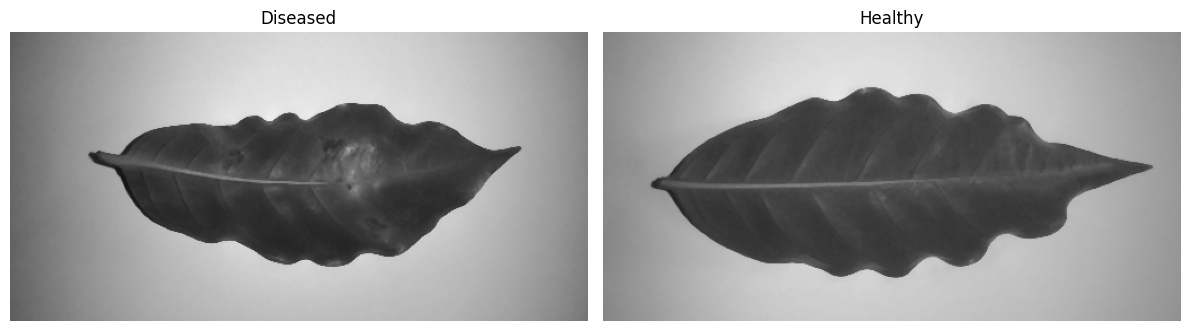

In [120]:
img_median = []

for img in img_grey:
    median_res = manual_median_filter(img, size=3)
    img_median.append(median_res)

img_median = np.array(img_median)
show_sample_images(img_median, labels, class_counter)

#### Penerapan Preprocessing Sharpening

Preprocessing kedua yang diterapkan adalah `Sharpening`, yang di mana dilakukan dengan cara meload seluruh citra pada variabel `img_median`, setiap citra kemudian diproses menggunakan fungsi `convolution` dengan kernel `k_sharp`. Setelah diproses menggunakan `convolution`, setiap citra kemudian dimasukkan ke dalam variabel `img_sharpened` dengan menggunakan fungsi `append`. Setelah itu variabel `img_sharpened` dikonversi menjadi `numpy array` agar dapat digunakan pada tahap pemrosesan berikutnya. Sebagai tahap akhir hasil citra yang telah di-sharpening ditampilkan menggunakan fungsi `show_sample_images()`.

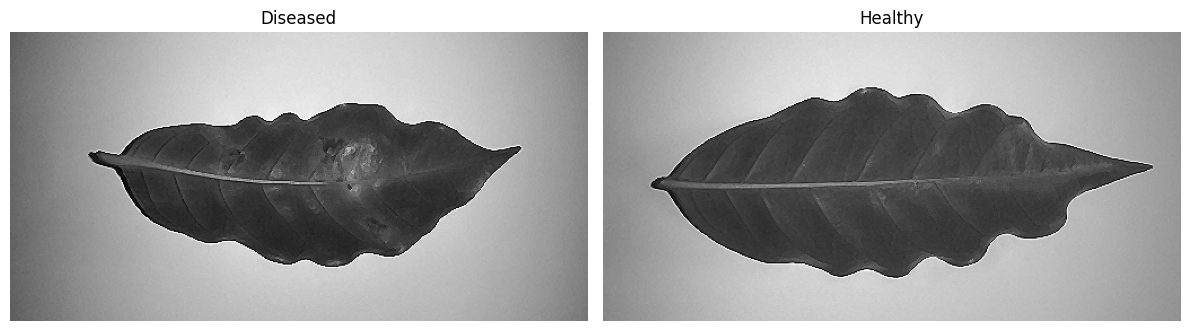

In [121]:
img_sharpened = []

for img in img_median:
    sharp_res = convolution(img, k_sharp)
    img_sharpened.append(sharp_res)

img_sharpened = np.array(img_sharpened)

show_sample_images(img_sharpened, labels, class_counter)

#### Penerapan Preprocessing Histogram Equalization

Preprocessing ketiga yang diterapkan adalah `Histogram Equalization`, yang di mana dilakukan dengan cara meload seluruh citra pada variabel `img_sharpened`, setiap citra kemudian diproses menggunakan fungsi `ekualisasi_histogram`. Setelah diproses menggunakan `ekualisasi_histogram`, setiap citra kemudian dimasukkan ke dalam variabel `img_equalized` dengan menggunakan fungsi `append`. Setelah itu variabel `img_equalized` dikonversi menjadi `numpy array` agar dapat digunakan pada tahap pemrosesan berikutnya. Sebagai tahap akhir hasil citra yang telah di-ekualisasi histogram ditampilkan menggunakan fungsi `show_sample_images()`.

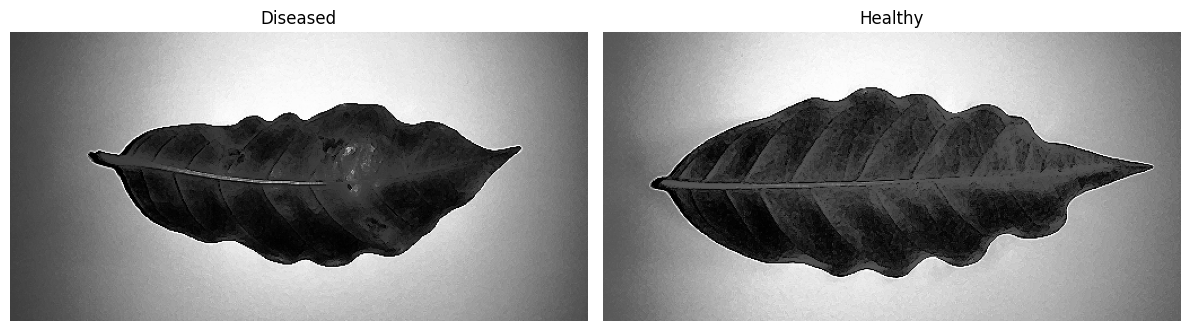

In [122]:
img_equalized = []

for img in img_sharpened:
    eq_res = ekualisasi_histogram(img)
    img_equalized.append(eq_res)

img_equalized = np.array(img_equalized)
show_sample_images(img_equalized, labels, class_counter)

#### Penerapan Preprocessing Dilasi

Preprocessing keempat yang diterapkan adalah `Dilasi`, yang di mana dilakukan dengan cara meload seluruh citra pada variabel `img_equalized`, setiap citra kemudian diproses menggunakan fungsi `dilasi` dengan kernel `kernel3f1`. Setelah diproses menggunakan `dilasi`, setiap citra kemudian dimasukkan ke dalam variabel `img_dilated` dengan menggunakan fungsi `append`. Setelah itu variabel `img_dilated` dikonversi menjadi `numpy array` agar dapat digunakan pada tahap pemrosesan berikutnya. Sebagai tahap akhir hasil citra yang telah di-dilasi ditampilkan menggunakan fungsi `show_sample_images()`.

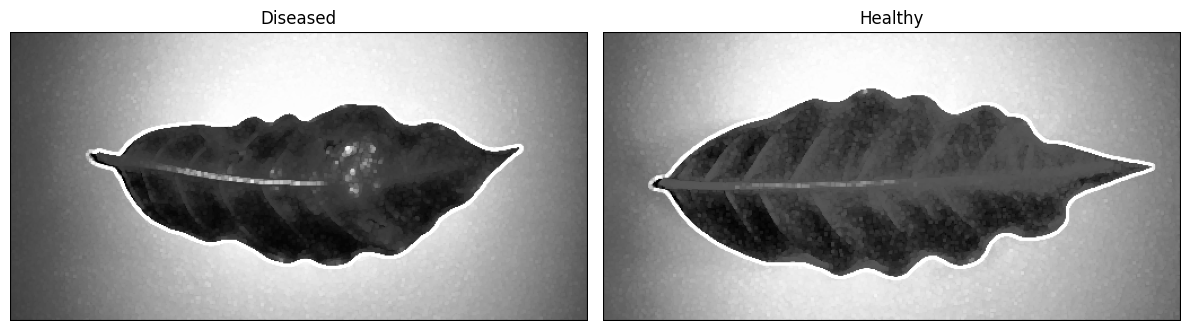

In [123]:
img_dilated = []

for img in img_equalized:
    dil_res = dilasi(img, kernel3f1)
    img_dilated.append(dil_res)

img_dilated = np.array(img_dilated)
show_sample_images(img_dilated, labels, class_counter)

#### Penerapan Preprocessing Erosi

Preprocessing kelima yang diterapkan adalah `Erosi`, yang di mana dilakukan dengan cara meload seluruh citra pada variabel `img_dilated`, setiap citra kemudian diproses menggunakan fungsi `erosi` dengan kernel `kernel3f1`. Setelah diproses menggunakan `erosi`, setiap citra kemudian dimasukkan ke dalam variabel `img_eroted` dengan menggunakan fungsi `append`. Setelah itu variabel `img_eroted` dikonversi menjadi `numpy array` agar dapat digunakan pada tahap pemrosesan berikutnya. Sebagai tahap akhir hasil citra yang telah di-erosi ditampilkan menggunakan fungsi `show_sample_images()`.

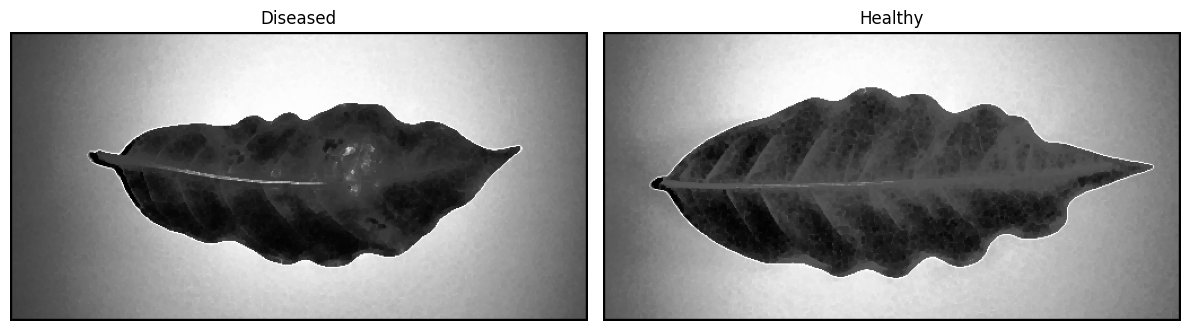

In [124]:
img_eroted = []

for img in img_dilated:
    er_res = erosi(img, kernel3f1)
    img_eroted.append(er_res)

img_eroted = np.array(img_eroted)
show_sample_images(img_eroted, labels, class_counter)

#### Penerapan Preprocessing Edge Detection (Sobel)

Preprocessing keenam yang diterapkan adalah `Edge Detection` menggunakan operator `Sobel`, yang di mana dilakukan dengan cara meload seluruh citra pada variabel `img_eroted`, setiap citra kemudian diproses menggunakan fungsi `get_edge` dengan kernel `sobelX` dan `sobelY`. Setelah diproses menggunakan `get_edge`, setiap citra kemudian dimasukkan ke dalam variabel `img_sobel` dengan menggunakan fungsi `append`. Setelah itu variabel `img_sobel` dikonversi menjadi `numpy array` agar dapat digunakan pada tahap pemrosesan berikutnya. Sebagai tahap akhir hasil citra yang telah di-deteksi tepi ditampilkan menggunakan fungsi `show_sample_images()`.

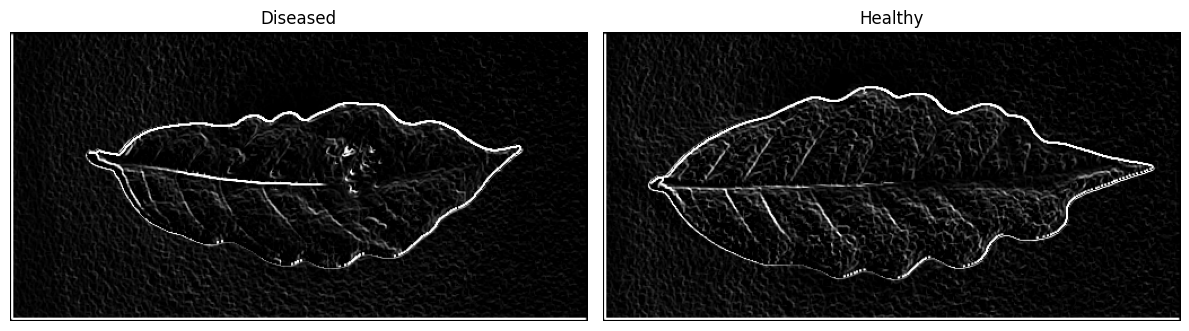

In [125]:
img_sobel = []

for img in img_eroted:
    sobel_res = get_edge(img, sobelX, sobelY)
    img_sobel.append(sobel_res)

img_sobel = np.array(img_sobel)
show_sample_images(img_sobel, labels, class_counter)

#### Penerapan Preprocessing Thresholding

Preprocessing ketujuh yang diterapkan adalah `Thresholding`, yang di mana dilakukan dengan cara meload seluruh citra pada variabel `img_sobel`, setiap citra kemudian diproses menggunakan fungsi `threshold` dengan nilai ambang (`threshold_value`) sebesar `50`. Setelah diproses menggunakan `threshold`, setiap citra kemudian dimasukkan ke dalam variabel `img_threshold` dengan menggunakan fungsi `append`. Setelah itu variabel `img_threshold` dikonversi menjadi `numpy array` agar dapat digunakan pada tahap pemrosesan berikutnya. Sebagai tahap akhir hasil citra yang telah di-threshold ditampilkan menggunakan fungsi `show_sample_images()`.

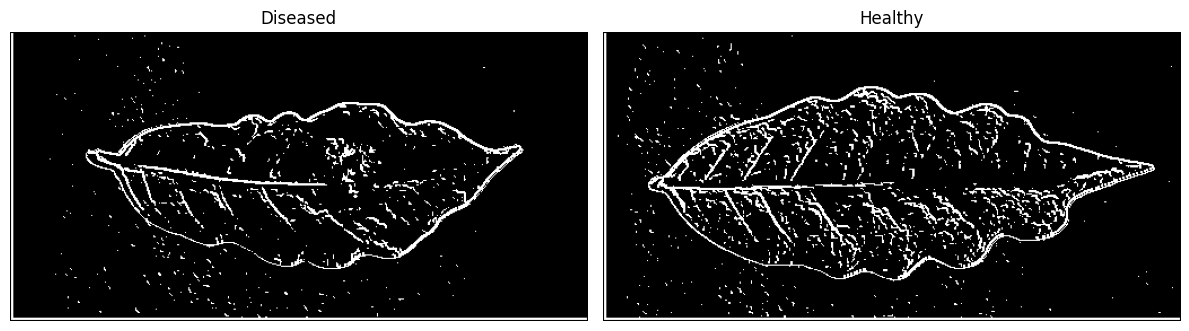

In [126]:
threshold_value = 50

img_threshold = []

for img in img_sobel:
    thresh_res = threshold(img, threshold_value)
    img_threshold.append(thresh_res)

img_threshold = np.array(img_threshold)

show_sample_images(img_threshold, labels, class_counter)

### Feature Extraction

In [127]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Fungsi `glcm(image, derajat)` digunakan untuk menghitung matriks GLCM (Gray Level Co-occurrence Matrix) dari citra grayscale pada sudut 0°, 45°, 90°, atau 135°. Dalam prosesnya, nilai derajat tersebut dikonversi menjadi radian agar kompatibel dengan `graycomatrix` dari pustaka `skimage.feature`. Perhitungan matriks ini menggunakan jarak 1 piksel dengan 256 tingkat keabuan, serta menerapkan opsi simetris dan normalisasi untuk menghasilkan matriks probabilitas yang seimbang. Hasil GLCM ini sangat krusial dalam ekstraksi fitur tekstur untuk analisis citra.

In [128]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

Fungsi `correlation(matriks)` menerima input berupa matriks GLCM untuk menghitung nilai korelasi tekstur melalui fungsi `graycoprops` dari pustaka `skimage.feature`. Nilai korelasi ini berfungsi untuk mengukur tingkat keterkaitan linear antara piksel-piksel pada pola tekstur tertentu. Karena matriks GLCM umumnya berbentuk format 4D, fungsi ini mengambil elemen pada indeks `[0, 0]` untuk mengisolasi nilai korelasi utamanya. Indikator korelasi ini sangat bermanfaat dalam menganalisis hubungan spasial antar-piksel di dalam citra.

In [129]:
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

Fungsi `dissimilarity(matriks)` memanfaatkan matriks GLCM sebagai input untuk menghitung nilai ketidakmiripan (dissimilarity) tekstur menggunakan fungsi `graycoprops` dari `skimage.feature`. Parameter dissimilarity ini berfungsi untuk mengukur tingkat perbedaan intensitas antara piksel yang saling bertetangga, sehingga memberikan gambaran mengenai variasi tekstur pada citra. Karena struktur GLCM yang dihasilkan biasanya berupa array 4D, fungsi ini mengekstrak elemen pada indeks `[0, 0]` untuk mengambil nilai ketidakmiripan utamanya. Nilai ini sangat berguna untuk menganalisis derajat perbedaan lokal di dalam pola tekstur gambar.

In [130]:
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

Fungsi `homogenity(matriks)` digunakan untuk mengukur tingkat keseragaman (homogeneity) tekstur dari input matriks GLCM menggunakan fungsi `graycoprops` dari pustaka `skimage.feature`. Nilai ini merepresentasikan seberapa konsisten atau seragam pola tekstur pada citra, di mana skor yang tinggi menandakan karakteristik tekstur yang lebih halus dan merata. Mengingat struktur matriks GLCM berbentuk format 4D, fungsi ini mengekstrak nilai pada indeks `[0, 0]` untuk mengambil data keseragaman utamanya. Fitur homogeneity ini memiliki peran penting dalam menganalisis keteraturan pola tekstur di dalam gambar.

In [131]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

Fungsi `contrast(matriks)` memproses input berupa matriks GLCM untuk menghitung nilai kontras (contrast) tekstur melalui fungsi `graycoprops` dari pustaka `skimage.feature`. Nilai kontras ini berfungsi untuk mengukur derajat variasi intensitas antar-piksel pada citra, di mana skor yang tinggi mengindikasikan perbedaan intensitas yang tajam atau tekstur yang cenderung lebih kasar. Karena format data GLCM yang dihasilkan berbentuk 4D, fungsi ini mengakses elemen pada indeks `[0, 0]` untuk mengambil nilai kontras utamanya. Fitur ini sangat berguna untuk mengevaluasi tingkat ketajaman serta perubahan pola spasial di dalam gambar.

In [132]:
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

Fungsi `ASM(matriks)` menggunakan input berupa matriks GLCM untuk menghitung nilai Angular Second Moment (ASM) atau energi tekstur lewat fungsi `graycoprops` dari pustaka `skimage.feature`. Nilai ASM ini merepresentasikan tingkat konsentrasi atau keteraturan pola spasial pada citra, di mana skor yang tinggi menandakan tekstur yang cenderung lebih seragam dan teratur. Karena struktur data GLCM yang dihasilkan berbasis format 4D, fungsi ini mengekstrak elemen pada indeks `[0, 0]` untuk mengambil nilai ASM utamanya. Parameter ini umumnya diandalkan untuk mengevaluasi homogenitas serta kekuatan pola tekstur di dalam gambar.

In [133]:
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

Fungsi `energy(matriks)` memproses input berupa matriks GLCM untuk menghasilkan nilai energi (energy) tekstur menggunakan fungsi `graycoprops` dari pustaka `skimage.feature`. Nilai energy sendiri didapatkan dari akar kuadrat Angular Second Moment (ASM) yang berfungsi untuk mengukur kekuatan atau intensitas pola spasial pada citra, di mana skor yang tinggi menunjukkan tekstur yang lebih konsisten dan teratur. Mengikuti struktur data GLCM yang berformat 4D, fungsi ini mengakses nilai pada indeks `[0, 0]` untuk mengambil data energi utamanya. Karakteristik energy ini sangat penting dalam mengevaluasi kekuatan serta keteraturan pola tekstur di dalam gambar.

In [134]:
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Fungsi `entropyGlcm(matriks)` menghitung nilai entropi dari matriks GLCM dengan cara meratakan dimensi matriks tersebut menjadi satu dimensi menggunakan fungsi `.ravel()`, kemudian menerapkan fungsi `entropy` dari modul `scipy.stats`. Nilai entropi ini digunakan untuk mengukur derajat ketidakpastian atau kompleksitas spasial pada citra, di mana skor yang tinggi mengindikasikan pola tekstur yang cenderung lebih acak, beragam, atau kompleks. Nilai ini sangat bermanfaat untuk mengevaluasi tingkat keacakan serta variasi fitur tekstur di dalam gambar.

In [135]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(img_threshold)):
    D0 = glcm(img_threshold[i], 0)
    D45 = glcm(img_threshold[i], 45)
    D90 = glcm(img_threshold[i], 90)
    D135 = glcm(img_threshold[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Blok kode ini menghitung matriks GLCM untuk setiap citra hasil `threshold (img_threshold)` pada empat variasi sudut, yaitu 0°, 45°, 90°, dan 135°. Pada setiap tahapan iterasi, fungsi glcm dijalankan dengan memproses gambar ke-i berdasarkan sudut-sudut tersebut, kemudian matriks GLCM yang terbentuk disimpan secara terpisah ke dalam list `Derajat0, Derajat45, Derajat90, dan Derajat135`. Melalui proses ini, setiap citra akan memiliki empat representasi matriks GLCM yang menangkap karakteristik tekstur dari berbagai arah, yang nantinya siap digunakan dalam tahapan ekstraksi fitur tekstur lanjutan.

In [136]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


Blok kode ini menyiapkan 24 list kosong yang dialokasikan untuk menampung nilai fitur tekstur hasil ekstraksi matriks GLCM pada empat orientasi sudut (0°, 45°, 90°, dan 135°). Setiap karakteristik tekstur meliputi `contrast, dissimilarity, homogeneity, entropy, ASM, energy, dan correlation` memiliki empat list penampung yang disesuaikan berdasarkan sudutnya, seperti `Kontras0` untuk orientasi 0°, `Kontras45` untuk orientasi 45°, dan begitu seterusnya. Struktur list ini nantinya akan diisi secara bertahap dengan skor fitur tekstur dari masing-masing citra guna mendukung proses analisis ekstraksi fitur lanjutan.

In [137]:
for i in range(len(img_threshold)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

Blok kode ini melakukan proses iterasi pada setiap citra hasil `threshold (img_threshold)` untuk mengekstrak nilai korelasi tekstur dari matriks GLCM yang telah dihitung sebelumnya. Dengan memanfaatkan fungsi `correlation()`, perhitungan fitur korelasi ini dilakukan secara spesifik pada empat orientasi sudut, yaitu 0°, 45°, 90°, dan 135°. Skor korelasi yang diperoleh dari tiap-tiap sudut kemudian dialokasikan ke dalam penampung yang selaras, yaitu `correlation0, correlation45, correlation90, dan correlation135`. Mekanisme ini memastikan seluruh parameter korelasi tekstur dari semua citra di setiap arah terdokumentasi secara terpisah untuk kebutuhan analisis maupun pemrosesan lanjutan.

In [138]:
for i in range(len(img_threshold)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

Blok kode ini menerapkan proses looping pada seluruh citra hasil `threshold (img_threshold)` guna menghitung nilai korelasi tekstur berdasarkan matriks GLCM yang telah diperoleh sebelumnya. Melalui fungsi `correlation()`, nilai korelasi tersebut diekstrak pada empat orientasi sudut, yakni 0°, 45°, 90°, dan 135°. Hasil perhitungan dari masing-masing arah kemudian dimasukkan ke dalam list penampung yang bersesuaian, yaitu `correlation0, correlation45, correlation90, dan correlation135`. Melalui tahapan ini, fitur korelasi tekstur dari setiap gambar pada semua sudut dapat terorganisasi secara terpisah untuk mempermudah analisis atau pemrosesan data selanjutnya.

In [139]:
for i in range(len(img_threshold)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

Blok kode ini mengeksekusi proses iterasi pada setiap citra hasil `threshold (img_threshold)` untuk menghitung fitur ketidakmiripan (dissimilarity) berdasarkan matriks GLCM yang telah tersedia. Dengan menggunakan fungsi `dissimilarity()`, nilai tersebut diekstrak dari empat orientasi sudut yang berbeda, yaitu 0°, 45°, 90°, dan 135°. Skor yang didapatkan dari masing-masing sudut kemudian disimpan ke dalam list penampung yang selaras, meliputi dissimilarity0, dissimilarity45, dissimilarity90, dan dissimilarity135.

In [140]:
for i in range(len(img_threshold)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

Blok kode ini menerapkan proses perulangan pada seluruh citra hasil `threshold (img_threshold)` untuk mengekstrak parameter keseragaman tekstur (homogeneity) dari matriks GLCM yang telah tersedia. Menggunakan fungsi `homogenity()`, perhitungan ini dilakukan secara spesifik pada empat orientasi sudut, yaitu 0°, 45°, 90°, dan 135°. Nilai keseragaman yang diperoleh dari setiap sudut kemudian dialokasikan ke dalam list penampung yang bersesuaian, meliputi `homogenity0, homogenity45, homogenity90, dan homogenity135`. Langkah ini berfungsi untuk memisahkan dan mengorganisasi data homogenitas tekstur citra dari berbagai arah guna mempermudah analisis lanjutan.

In [141]:
for i in range(len(img_threshold)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

Blok kode ini mengekstrak nilai entropi tekstur dari setiap citra hasil `threshold (img_threshold)` berdasarkan matriks GLCM yang dihitung pada empat orientasi sudut (0°, 45°, 90°, dan 135°) menggunakan fungsi `entropyGlcm()`. Skor entropi yang diperoleh dari masing-masing sudut kemudian disimpan ke dalam list penampung yang bersesuaian, yaitu `entropy0, entropy45, entropy90, dan entropy135`. Parameter entropi ini berfungsi untuk mengukur derajat kompleksitas atau keacakan pola spasial citra dari berbagai arah, yang menjadi komponen penting dalam analisis karakteristik tekstur gambar.

In [142]:
for i in range(len(img_threshold)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

Blok kode ini melakukan perulangan pada setiap citra hasil `threshold (img_threshold)` untuk mengekstrak fitur `Angular Second Moment (ASM)` dari matriks GLCM yang tersedia pada empat orientasi sudut (0°, 45°, 90°, dan 135°) menggunakan fungsi ASM(). Skor ASM yang didapatkan dari masing-masing sudut kemudian disimpan ke dalam list penampung yang bersesuaian, yaitu `ASM0, ASM45, ASM90, dan ASM135`. Parameter ASM ini digunakan untuk mengukur derajat keteraturan serta tingkat homogenitas pola spasial pada citra, menjadikannya komponen penting dalam analisis tekstur yang mendalam.

In [143]:
for i in range(len(img_threshold)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Blok kode ini menerapkan proses looping pada seluruh citra hasil `threshold (img_threshold)` untuk menghitung fitur energi (energy) tekstur berdasarkan matriks GLCM yang dihitung pada empat orientasi sudut (0°, 45°, 90°, dan 135°) menggunakan fungsi `energy()`. Nilai energi yang didapatkan dari masing-masing sudut kemudian disimpan ke dalam list penampung yang bersesuaian, meliputi `energy0, energy45, energy90, dan energy135`. Parameter energy ini berfungsi untuk merepresentasikan tingkat kekuatan serta konsistensi pola spasial citra dari berbagai arah guna mendukung analisis tekstur yang lebih komprehensif.

### Write the extraction's results to CSV 

In [144]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,100.jpg,Diseased,3621.668221,5352.504892,4571.074219,5961.311155,0.944304,0.917687,0.929704,0.908324,...,0.776425,0.758227,0.888519,0.875192,0.881150,0.870763,0.647355,0.480666,0.555700,0.421595
1,101.jpg,Diseased,3457.634387,4911.369863,4169.648438,5612.994129,0.946827,0.924471,0.935877,0.913681,...,0.795984,0.776869,0.897723,0.886517,0.892179,0.881401,0.630085,0.476436,0.554709,0.401641
2,102.jpg,Diseased,3517.283054,5041.115460,4476.445312,6021.193738,0.945910,0.922475,0.931159,0.907403,...,0.779770,0.759572,0.890497,0.878681,0.883046,0.871534,0.652927,0.504323,0.559065,0.407955
3,103.jpg,Diseased,3526.230354,4840.508806,4233.398438,5728.767123,0.945772,0.925560,0.934897,0.911900,...,0.789530,0.769789,0.894077,0.883872,0.888555,0.877376,0.636871,0.503303,0.564825,0.412156
4,104.jpg,Diseased,4634.701413,6449.354207,5383.886719,7263.757339,0.928725,0.900819,0.917204,0.888295,...,0.734366,0.710752,0.862809,0.848902,0.856951,0.843061,0.623608,0.478040,0.563519,0.412129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,789.jpg,Healthy,4501.486057,6215.812133,5174.707031,6905.459883,0.930774,0.904410,0.920421,0.893805,...,0.753070,0.731095,0.873033,0.859977,0.867796,0.855041,0.600718,0.450582,0.541806,0.389623
196,790.jpg,Healthy,4213.184167,5677.866928,5065.136719,6740.782779,0.935208,0.912683,0.922106,0.896337,...,0.761169,0.739785,0.879031,0.867761,0.872450,0.860108,0.611339,0.478064,0.533570,0.380355
197,791.jpg,Healthy,3789.678633,5336.536204,4720.488281,6231.780822,0.941721,0.917932,0.927406,0.904165,...,0.768566,0.748950,0.883910,0.871934,0.876679,0.865419,0.644241,0.500791,0.557642,0.417045
198,8.jpg,Healthy,3312.489298,4871.448141,4166.660156,5416.379648,0.949059,0.925085,0.935923,0.916704,...,0.792903,0.776253,0.897101,0.885047,0.890451,0.881052,0.653133,0.491706,0.564468,0.434847


Blok kode ini menyusun dictionary `dataTable` yang berisi seluruh fitur tekstur hasil ekstraksi citra, seperti identitas file (Image_1, Image_2, dst), label kelas, serta parameter GLCM pada keempat sudut (0°, 45°, 90°, dan 135°) meliputi `contrast, homogeneity, dissimilarity, entropy, ASM, energy, dan correlation`. Data tersebut kemudian dikonversi menjadi `DataFrame pandas` dan diekspor ke dalam file `hasil_ekstraksi_pros1.csv`, yang selanjutnya dimuat kembali ke variabel `hasilEkstrak`.

## Feature Selection
Blok kode ini melakukan seleksi fitur dengan menghitung matriks korelasi pada dataset awal (tanpa kolom Label dan Filename) guna mengeliminasi fitur yang mengalami multikolinieritas berdasarkan nilai `threshold 0.95`. Jika sepasang fitur memiliki korelasi mencapai atau melebihi ambang batas tersebut, salah satu fitur akan dibuang sehingga menghasilkan subset fitur baru yang disimpan dalam variabel `x_new`, sementara label target dipisahkan ke variabel `y`. Selanjutnya, matriks korelasi dari fitur-fitur terpilih (x_new) divisualisasikan menggunakan heatmap dari pustaka seaborn dengan ukuran matriks 17x17 inci. Heatmap ini menampilkan angka korelasi hingga dua angka desimal dan menggunakan skema warna Blues untuk membantu mengevaluasi keterkaitan antar-fitur yang lolos seleksi.

<Axes: >

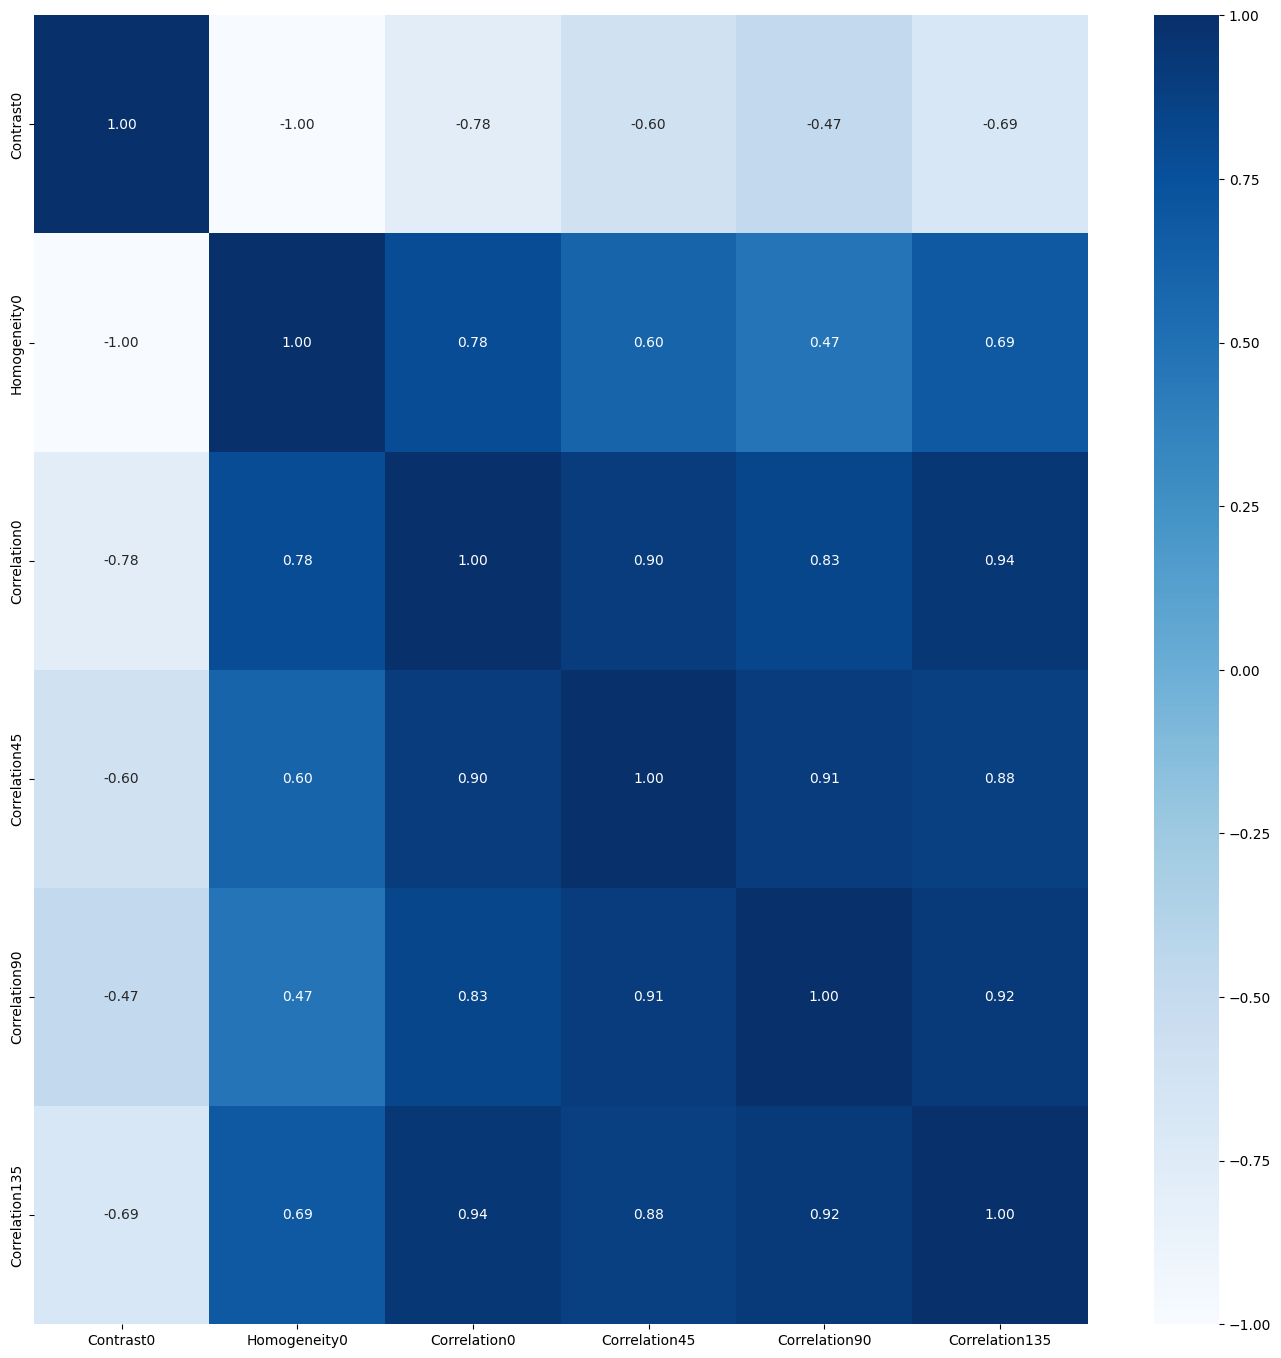

In [145]:
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

## Splitting Data

Blok kode ini membagi dataset menjadi data latih dan data uji menggunakan fungsi `train_test_split` dengan proporsi 70% untuk pelatihan (`X_train` dan `y_train`) serta 30% untuk pengujian (`X_test` dan `y_test`). Parameter `random_state=42` digunakan agar hasil pembagian data tetap konsisten setiap kali kode dijalankan. Terakhir, perintah print digunakan untuk menampilkan dimensi (shape) dari `X_train` dan `X_test` guna memastikan jumlah baris dan kolom data telah terbagi dengan benar.

In [146]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)

(140, 6)
(60, 6)


## Feature Normalization

Blok kode ini melakukan proses standardisasi data (`Z-score normalization`) secara manual pada fitur-fitur dataset. Langkah pertama adalah menghitung nilai rata-rata (`mean_train`) dan simpangan baku (`std_train`) dari setiap fitur hanya pada data latih `X_train`. Selanjutnya, fitur pada data latih `X_train` dan data uji `X_test` ditransformasikan dengan cara dikurangi `mean_train` lalu dibagi dengan `std_train`. Penggunaan statistik data latih untuk menstandardisasi data uji bertujuan untuk mencegah kebocoran data (data leakage) sehingga evaluasi model tetap objektif.

In [147]:
mean_train = X_train.mean()
std_train = X_train.std()

X_train = (X_train - mean_train) / std_train
X_test = (X_test - mean_train) / std_train

## Modeling

### Define Model

In [148]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

Blok kode ini melakukan proses pelatihan dan evaluasi untuk model Random Forest (`rf`). Model dilatih menggunakan data latih melalui perintah `rf.fit`(`X_train, y_train`). Setelah itu, performa model dievaluasi pada dua tahapan: pertama pada data latih (Training Set) dan kedua pada data uji (Testing Set). Pada masing-masing tahapan, model melakukan prediksi menggunakan `rf.predict()` yang hasilnya disimpan dalam `variabel y_pred`, kemudian fungsi generateClassificationReport dipanggil untuk mencetak metrik performa seperti laporan klasifikasi, confusion matrix, dan nilai akurasi untuk dianalisis lebih lanjut.

In [149]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

    Diseased       0.97      0.97      0.97        69
     Healthy       0.97      0.97      0.97        71

    accuracy                           0.97       140
   macro avg       0.97      0.97      0.97       140
weighted avg       0.97      0.97      0.97       140

[[67  2]
 [ 2 69]]
Accuracy: 0.9714285714285714

------Testing Set------
              precision    recall  f1-score   support

    Diseased       0.69      0.77      0.73        31
     Healthy       0.72      0.62      0.67        29

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60

[[24  7]
 [11 18]]
Accuracy: 0.7


### 1. Hasil Evaluasi Performa Model

Evaluasi dilakukan menggunakan subset data latih (Training Set) dan data uji (Testing Set) untuk meninjau akurasi serta kemampuan model dalam beradaptasi dengan variasi citra yang baru. Rincian metrik yang diperoleh adalah sebagai berikut:

* Akurasi (Accuracy): Model mencatat hasil yang sangat tinggi pada sesi latihan dengan akurasi sebesar 97.14%. Pada saat dilakukan pengujian dengan data baru, performa akurasinya berada di angka 70.00%, di mana model berhasil menebak 42 sampel dari total 60 data uji secara tepat.
* Precision (Presisi): Pada sesi pengujian, nilai presisi untuk kelas Diseased berada di angka 0.69, sedangkan untuk kelas Healthy mencatatkan nilai 0.72. Hal ini menunjukkan tingkat ketepatan model dalam mengelompokkan gambar sesuai dengan kategori aslinya.
* Recall (Sensitivitas): Nilai recall untuk kelas Diseased pada data uji mencapai 0.77. Artinya, dari 31 gambar yang aslinya sakit, model berhasil mengidentifikasi 24 gambar dengan benar. Sementara untuk kelas Healthy, nilai recall yang didapat adalah 0.62, di mana 18 dari 29 gambar sehat berhasil terdeteksi.
* F1-Score: Metrik keseimbangan antara presisi dan recall menghasilkan nilai seimbang di angka 0.97 pada sesi latihan, serta mencatatkan angka 0.73 untuk kelas sakit dan 0.67 untuk kelas sehat pada sesi pengujian.

---

### 2. Analisis Confusion Matrix

Penyebaran tebakan benar dan salah dari sistem dipetakan secara riil melalui tabel berikut:

| Kelompok Data | Benar Sakit (Diseased) | Benar Sehat (Healthy) | Tebakan yang Salah |
| :--- | :---: | :---: | :--- |
| Data Latih (Training) | 67 | 69 | 4 sampel (2 sakit ditebak sehat, 2 sehat ditebak sakit) |
| Data Uji (Testing) | 24 | 18 | 18 sampel (7 sakit ditebak sehat, 11 sehat ditebak sakit) |

* Matriks Data Latih [[67, 2], [2, 69]]: Dari total 140 data yang digunakan untuk melatih sistem, model menunjukkan penguasaan materi yang sangat baik dengan hanya melakukan 4 kesalahan tebakan.
* Matriks Data Uji [[24, 7], [11, 18]]: Dari 60 data uji yang diberikan, model berhasil mengamankan sebagian besar prediksi dengan benar, meskipun masih menyisakan 7 gambar sakit yang dikira sehat dan 11 gambar sehat yang dikira sakit.

---

### 3. Kesimpulan

Secara keseluruhan, hasil percobaan ini menunjukkan bahwa model telah berhasil mempelajari karakteristik dasar dari pola tekstur citra pada data latihan. Adanya perbedaan angka akurasi antara masa latihan sebesar 97.14% dan masa pengujian sebesar 70.00% merupakan hal yang wajar dalam eksperimen machine learning, yang menandakan adanya tantangan tersendiri bagi model saat berhadapan dengan variasi baru pada data uji.

Kelebihan dari model dalam pengujian ini terlihat pada nilai recall kelas sakit yang menyentuh angka 77%. Kemampuan menjaring sebagian besar citra berpenyakit ini menjadi modal awal yang berharga untuk sistem deteksi. Hasil evaluasi ini memberikan gambaran yang jelas mengenai batasan performa saat ini, sekaligus membuka peluang untuk pengembangan berikutnya melalui optimasi parameter model agar lebih siap dalam mengenali data baru yang lebih beragam.

### Train SVM Classifier

Blok kode ini melakukan proses pelatihan dan evaluasi untuk model SVM (`svm`). Model dilatih menggunakan data latih melalui perintah `svm.fit`(`X_train, y_train`). Setelah itu, performa model diuji pada dua skenario berbeda, yaitu pada data latih (Training Set) dan data uji (Testing Set). Pada setiap skenario, model menghasilkan prediksi label menggunakan `svm.predict(X_train)` dan `svm.predict(X_test)` yang disimpan dalam variabel `y_pred`, lalu fungsi generateClassificationReport dipanggil untuk mencetak metrik performa lengkap termasuk laporan klasifikasi, confusion matrix, dan nilai akurasi.

In [150]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Diseased       0.78      0.97      0.86        69
     Healthy       0.96      0.73      0.83        71

    accuracy                           0.85       140
   macro avg       0.87      0.85      0.85       140
weighted avg       0.87      0.85      0.85       140

[[67  2]
 [19 52]]
Accuracy: 0.85

------Testing Set------
              precision    recall  f1-score   support

    Diseased       0.72      0.94      0.82        31
     Healthy       0.90      0.62      0.73        29

    accuracy                           0.78        60
   macro avg       0.81      0.78      0.78        60
weighted avg       0.81      0.78      0.78        60

[[29  2]
 [11 18]]
Accuracy: 0.7833333333333333


### 1. Hasil Evaluasi Performa Model

Evaluasi dilakukan menggunakan subset data latih (Training Set) dan data uji (Testing Set) untuk melihat kemampuan model dalam mengenali data lama dan menggeneralisasi data baru. Ringkasan metrik dari laporan klasifikasi adalah sebagai berikut:

* Akurasi (Accuracy): Model mencatatkan akurasi sebesar 85.00% pada sesi latihan. Menariknya, saat diuji dengan data baru yang belum pernah dilihat sebelumnya, performa model tetap stabil dan berada di angka 78.33%, di mana model berhasil menebak 47 sampel dari total 60 data uji dengan benar.
* Precision (Presisi): Pada data uji, nilai presisi untuk kategori Diseased berada di angka 0.72. Sementara itu, untuk kategori Healthy nilainya cukup tinggi yaitu mencapai 0.90, yang menandakan tingkat ketepatan tebakan model saat menentukan gambar sehat sangat bisa diandalkan.
* Recall (Sensitivitas): Nilai recall untuk kelas Diseased menunjukkan hasil yang sangat memuaskan, yaitu sebesar 0.94 pada data uji. Artinya, dari 31 gambar yang aslinya sakit, model sukses mengidentifikasi 29 gambar secara tepat. Untuk kelas Healthy, nilai recall yang diperoleh adalah 0.62.
* F1-Score: Metrik keseimbangan antara presisi dan recall menghasilkan nilai sebesar 0.82 untuk kategori sakit dan 0.73 untuk kategori sehat pada sesi pengujian.

---

### 2. Analisis Confusion Matrix

Penyebaran angka tebakan benar dan salah dari model dipetakan secara mendetail melalui tabel berikut:

| Kelompok Data | Benar Sakit (Diseased) | Benar Sehat (Healthy) | Tebakan yang Salah |
| :--- | :---: | :---: | :--- |
| Data Latih (Training) | 67 | 52 | 21 sampel (2 sakit ditebak sehat, 19 sehat ditebak sakit) |
| Data Uji (Testing) | 29 | 18 | 13 sampel (2 sakit ditebak sehat, 11 sehat ditebak sakit) |

* Matriks Data Latih [[67, 2], [19, 52]]: Dari total 140 data untuk latihan, model berhasil mengklasifikasikan bagian besar data dengan tepat, dengan kecenderungan sangat sensitif terhadap gambar yang sakit.
* Matriks Data Uji [[29, 2], [11, 18]]: Dari total 60 data uji, model menunjukkan konsistensi yang baik dengan berhasil mengamankan 29 gambar sakit dan 18 gambar sehat sesuai label aslinya.

---

### 3. Kesimpulan

Secara keseluruhan, hasil percobaan kali ini menunjukkan performa model yang stabil. Selisih akurasi yang tidak terlalu jauh antara data latih (85.00%) dan data uji (78.33%) membuktikan bahwa model memiliki kemampuan adaptasi yang baik dan terhindar dari masalah salah hafal atau overfitting.

Kelebihan utama dari model pada eksperimen ini terletak pada nilai recall kelas sakit yang sangat tinggi, yaitu mencapai 94% pada data uji. Dalam sistem diagnosis awal, kemampuan untuk menjaring hampir seluruh objek yang sakit tanpa melewatkannya adalah capaian yang sangat bagus dan krusial. Hasil ini menjadi modal awal yang kuat untuk pengembangan sistem ke depan, di mana optimasi berikutnya dapat difokuskan pada peningkatan akurasi kelas sehat agar performa model menjadi lebih seimbang.

### Train KNN Classifier

Blok kode ini melakukan proses pelatihan dan evaluasi untuk model k-NN (`knn`). Model dilatih menggunakan data latih melalui perintah `knn.fit`(`X_train, y_train`). Setelah itu, performa model dievaluasi pada data latih (Training Set) dan data uji (Testing Set). Pada masing-masing tahapan, model memprediksi label kelas menggunakan `knn.predict()`, lalu fungsi generateClassificationReport dipanggil untuk menampilkan metrik performa lengkap seperti laporan klasifikasi, confusion matrix, dan nilai akurasi hasil prediksi tersebut.

In [151]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
              precision    recall  f1-score   support

    Diseased       0.86      0.90      0.88        69
     Healthy       0.90      0.86      0.88        71

    accuracy                           0.88       140
   macro avg       0.88      0.88      0.88       140
weighted avg       0.88      0.88      0.88       140

[[62  7]
 [10 61]]
Accuracy: 0.8785714285714286

------Testing Set------
              precision    recall  f1-score   support

    Diseased       0.76      0.84      0.80        31
     Healthy       0.81      0.72      0.76        29

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.79      0.78      0.78        60

[[26  5]
 [ 8 21]]
Accuracy: 0.7833333333333333


### 1. Hasil Evaluasi Performa Model

Evaluasi dilakukan menggunakan subset data latih (Training Set) dan data uji (Testing Set) untuk mengukur tingkat akurasi serta keseimbangan model dalam mengenali setiap kategori kelas. Berikut adalah ringkasan metrik dari laporan klasifikasi:

* Akurasi (Accuracy): Model mencatat angka akurasi yang solid sebesar 87.86% pada sesi latihan. Ketika diuji menggunakan data baru yang belum pernah dipelajari, model mempertahankan stabilitas kinerjanya dengan akurasi sebesar 78.33%, di mana 47 dari total 60 gambar uji berhasil ditebak dengan benar.
* Precision (Presisi): Pada data uji, nilai presisi untuk kategori Diseased berada di angka 0.76. Sementara itu, untuk kategori Healthy nilainya mencapai 0.81, yang menunjukkan bahwa tingkat ketepatan model saat menebak gambar sehat sudah cukup tinggi dan minim salah deteksi.
* Recall (Sensitivitas): Nilai recall untuk kelas Diseased berada di angka 0.84 pada data uji. Hal ini berarti dari total 31 gambar yang kondisi aslinya sakit, model sukses mengidentifikasi 26 gambar di antaranya. Untuk kelas Healthy, nilai recall yang diperoleh berada di angka 0.72, dengan 21 dari 29 gambar sehat berhasil terjaring.
* F1-Score: Metrik keseimbangan antara presisi dan recall mencatatkan angka yang harmonis, yaitu sebesar 0.80 untuk kategori sakit dan 0.76 untuk kategori sehat pada sesi pengujian.

---

### 2. Analisis Confusion Matrix

Penyebaran angka tebakan benar dan salah dari model dipetakan secara nyata melalui tabel berikut:

| Kelompok Data | Benar Sakit (Diseased) | Benar Sehat (Healthy) | Tebakan yang Salah |
| :--- | :---: | :---: | :--- |
| Data Latih (Training) | 62 | 61 | 17 sampel (7 sakit ditebak sehat, 10 sehat ditebak sakit) |
| Data Uji (Testing) | 26 | 21 | 13 sampel (5 sakit ditebak sehat, 8 sehat ditebak sakit) |

* Matriks Data Latih [[62, 7], [10, 61]]: Dari total 140 data yang digunakan untuk latihan, model menunjukkan penguasaan pola yang merata dengan berhasil menebak 62 gambar sakit dan 61 gambar sehat secara tepat.
* Matriks Data Uji [[26, 5], [8, 21]]: Dari total 60 data uji, model menunjukkan performa yang konsisten dengan mengamankan mayoritas prediksi benar, yaitu 26 gambar sakit dan 21 gambar sehat sesuai label aslinya.

---

### 3. Kesimpulan

Secara keseluruhan, hasil percobaan kali ini menunjukkan performa model yang stabil. Jarak akurasi yang tergolong dekat antara sesi latihan (87.86%) dan sesi pengujian (78.33%) membuktikan bahwa model memiliki kemampuan generalisasi yang baik serta aman dari masalah salah hafal atau overfitting.

Kelebihan utama dari model ini terletak pada performanya yang seimbang dalam mengenali kedua kelas, baik citra sakit maupun citra sehat. Nilai recall kelas sakit yang mencapai 84% pada data uji memberikan jaminan yang cukup baik bahwa sebagian besar objek berpenyakit dapat terdeteksi dengan sukses. Hasil ini menjadi fondasi eksperimen yang matang dan sangat potensial untuk ditingkatkan lebih lanjut pada penelitian atau pengembangan berikutnya.

## Evaluation With Confusion Matrix
Blok kode ini mendefinisikan fungsi `plot_confusion_matrix` untuk memvisualisasikan matriks kekacauan (confusion matrix) secara grafis menggunakan kelas `ConfusionMatrixDisplay` dari pustaka `sklearn.metrics`. Fungsi ini menerima input berupa label asli `y_true`, label prediksi `y_pred`, dan title untuk judul grafik, lalu menampilkan matriks tersebut dengan skema warna gradasi biru (`cmap=plt.cm.Blues`). Selanjutnya, fungsi ini dipanggil sebanyak tiga kali untuk menggambarkan dan menampilkan confusion matrix dari masing-masing model pada data uji `X_test`, yaitu untuk model Random Forest (`rf`), SVM (`svm`), dan k-NN (`knn`).

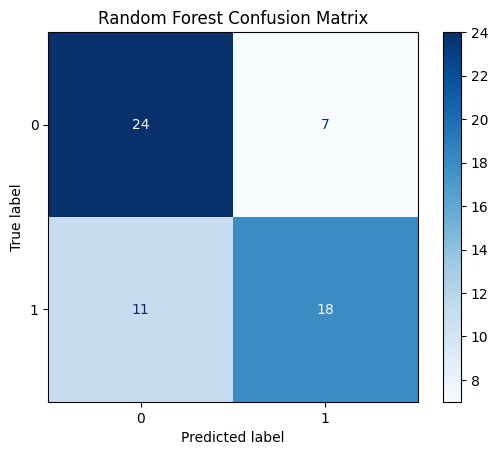

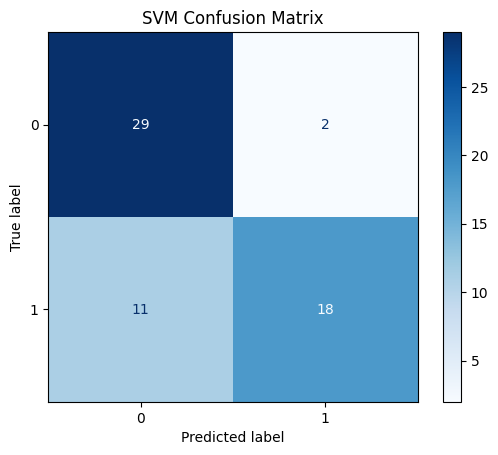

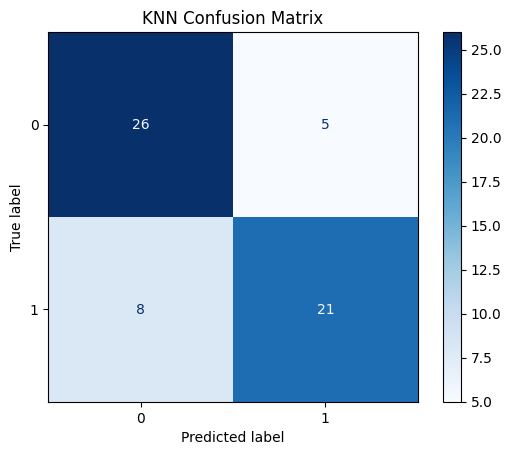

In [152]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")